# Quantum Portfolio Optimization on the Nairobi Securities Exchange

**Project:** QS-FinTech-T2

This notebook is adapted from Qiskit's standard portfolio optimization
tutorial, with one central change: instead of `RandomDataProvider`
generating synthetic prices, every solver here runs on **real daily
closing-price data for Nairobi Securities Exchange (NSE) listed
companies** (`NSE_data_all_stocks_2025.csv`, 208 trading days, Jan-Oct
2025).

The goal of the project is not just to solve the portfolio problem once,
but to **benchmark four different solving approaches on the identical
problem instance**:

1. **Classical (exact)** - `NumPyMinimumEigensolver`, used as ground truth
2. **Quantum annealing** - QUBO solved via simulated annealing (`neal`),
   with a real D-Wave hardware path available when run in an environment
   with Leap/qBraid access
3. **SamplingVQE** - a gate-based variational algorithm with a
   hardware-efficient ansatz
4. **QAOA** - the Quantum Approximate Optimization Algorithm, purpose-built
   for combinatorial problems like this one

Comparing these four side by side is the actual point of the project:
each represents a genuinely different strategy for solving the same
NP-hard combinatorial optimization problem, and they have very different
cost/scalability/optimality trade-offs in practice.

## 1. Problem definition

We solve the standard mean-variance portfolio optimization problem for
$n$ assets, formulated as a QUBO (Quadratic Unconstrained Binary
Optimization once the constraint is folded in as a penalty):

$$\begin{aligned}
\min_{x \in \{0, 1\}^n}  q \, x^T \Sigma x - \mu^T x\\
\text{subject to: } \mathbf{1}^T x = B
\end{aligned}$$

where:

- $x \in \{0, 1\}^n$ - a binary decision for each asset: included in the
  portfolio (1) or not (0)
- $\mu \in \mathbb{R}^n$ - expected (mean) return of each asset
- $\Sigma \in \mathbb{R}^{n \times n}$ - the covariance matrix of asset
  returns
- $q$ - the risk-aversion factor (higher $q$ penalizes variance more
  heavily relative to return)
- $B$ - the budget: exactly how many of the $n$ assets to hold

This is a cardinality-constrained selection problem - genuinely
combinatorial, not solvable as a plain continuous QP, which is exactly
why it's a natural target for QUBO-based classical and quantum solvers.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.result import QuasiDistribution
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

import dimod
import neal

print("Imports OK")

Imports OK


## 2. Load real NSE data

We use eight liquid, well-known NSE blue-chip tickers spanning banking,
telecom, and consumer goods, and compute daily returns from their closing
prices over the available window.

> **Note on the data pipeline:** the raw NSE export used ticker codes as
> column headers (`SCOM`, `EQTY`, `KCB`, ...), which is what the ticker
> list below expects. An earlier version of the project's data folder
> also contained a differently-processed export using full company names
> as headers (`"Safaricom Plc"` instead of `"SCOM"`) - loading that file
> against this ticker list raises a `KeyError`, since none of the names
> match. The file loaded below is the ticker-coded version.

In [2]:
CSV_PATH = "NSE_data_all_stocks_2025.csv"   # ticker-coded columns

TICKERS = ["SCOM", "EQTY", "KCB", "EABL", "BAT", "COOP", "BAMB", "JUB"]

q = 0.5                      # risk aversion factor
budget = len(TICKERS) // 2   # number of assets to select (4 of 8 here)

prices = pd.read_csv(CSV_PATH, parse_dates=["Date"]).set_index("Date")
prices = prices[TICKERS].sort_index()

missing = prices.isna().sum()
if missing.any():
    prices = prices.ffill().bfill()

returns = prices.pct_change().dropna()

mu = returns.mean().values
sigma = returns.cov().values

print(f"Loaded {len(prices)} trading days "
      f"({prices.index.min().date()} to {prices.index.max().date()}) "
      f"for {len(TICKERS)} NSE tickers: {TICKERS}\n")

print("Annualized mean return (%) per asset (252 trading days):")
for t, m in zip(TICKERS, mu):
    print(f"  {t:6s}  {m * 252 * 100:6.2f}%")

Loaded 208 trading days (2025-01-02 to 2025-10-31) for 8 NSE tickers: ['SCOM', 'EQTY', 'KCB', 'EABL', 'BAT', 'COOP', 'BAMB', 'JUB']

Annualized mean return (%) per asset (252 trading days):
  SCOM     71.74%
  EQTY     41.53%
  KCB      48.99%
  EABL     38.42%
  BAT      24.07%
  COOP     27.67%
  BAMB    -12.79%
  JUB      81.95%


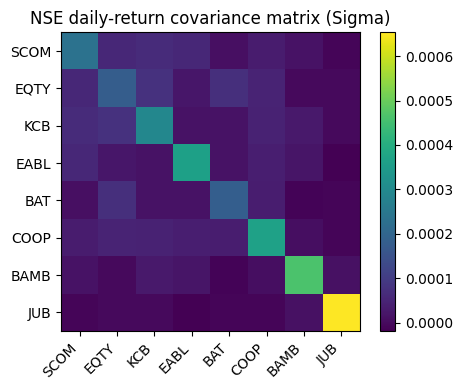

In [3]:
# Covariance heatmap of real NSE daily returns
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sigma, interpolation="nearest", cmap="viridis")
ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS)
ax.set_title("NSE daily-return covariance matrix (Sigma)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 3. Build the QUBO

`qiskit-finance`'s `PortfolioOptimization` application turns `mu`,
`sigma`, `q`, and `budget` directly into a `QuadraticProgram` - the same
object every solver below operates on, so all four approaches are
guaranteed to be solving the identical problem instance.

In [4]:
portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
print(qp.prettyprint())

Problem name: Portfolio optimization

Minimize
  0.0001168745675594891*x_0^2 + 5.612801152647036e-05*x_0*x_1
  + 6.278957985248986e-05*x_0*x_2 + 5.4674110069462786e-05*x_0*x_3
  + 7.716131707408104e-06*x_0*x_4 + 3.061151284816194e-05*x_0*x_5
  + 1.4363609220395802e-05*x_0*x_6 - 9.020970197546044e-06*x_0*x_7
  + 8.981089688700944e-05*x_1^2 + 7.598667770428601e-05*x_1*x_2
  + 2.1308958860480314e-05*x_1*x_3 + 7.171607190942419e-05*x_1*x_4
  + 4.637327248140636e-05*x_1*x_5 - 3.3685933604996028e-06*x_1*x_6
  - 2.233301972951915e-06*x_1*x_7 + 0.00014573197043027768*x_2^2
  + 1.2992854050947983e-05*x_2*x_3 + 1.2524541493741203e-05*x_2*x_4
  + 4.537822151814727e-05*x_2*x_5 + 2.750287299323444e-05*x_2*x_6
  - 2.46350180645509e-06*x_2*x_7 + 0.00018215904195234312*x_3^2
  + 1.2836570810761072e-05*x_3*x_4 + 3.7288364931231866e-05*x_3*x_5
  + 1.8523712692245424e-05*x_3*x_6 - 1.939339775933284e-05*x_3*x_7
  + 9.096984024527917e-05*x_4^2 + 3.509873391651344e-05*x_4*x_5
  - 1.4104011368910798e-05*x_4*

## 4. Shared result utilities

Both the exact solver and the two variational quantum solvers return
their answer as a probability distribution over bitstrings (an "eigen
state"). This helper normalizes across the different result types
(`QuasiDistribution` for the exact solver, plain dicts for sampled
quantum results) and prints the same report format for each.

In [5]:
def print_result(result, top_n=5):
    selection = result.x
    value = result.fval
    print(f"Optimal: selection {selection}, value {value:.6f}\n")

    eigenstate = result.min_eigen_solver_result.eigenstate
    if isinstance(eigenstate, QuasiDistribution):
        probabilities = eigenstate.binary_probabilities()
    elif isinstance(eigenstate, dict):
        probabilities = eigenstate
    else:
        probabilities = {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}

    probabilities = sorted(probabilities.items(), key=lambda item: item[1], reverse=True)
    print(f"{'selection':<20}{'value':>12}{'probability':>14}")
    for bitstring, prob in probabilities[:top_n]:
        x = np.array([int(b) for b in reversed(bitstring)])
        val = qp.objective.evaluate(x)
        print(f"{str(x):<20}{val:>12.4f}{prob:>14.4f}")

    return selection, value


def summarize(selection, value, label):
    chosen = [TICKERS[i] for i, bit in enumerate(selection) if bit == 1]
    print(f"\n{label}")
    print(f"  portfolio      : {chosen}")
    print(f"  objective value: {value:.6f}")
    return chosen


results_table = []   # each entry: (method, chosen_tickers, objective_value, extra_info)

## 5. Classical solution (`NumPyMinimumEigensolver`)

This solves the QUBO exactly via brute-force diagonalization - it is the
ground truth every other method below is measured against. It scales
poorly (exponentially in the number of assets), which is precisely why
the other three methods exist, but for a small asset universe like this
one it's the fastest and most reliable of the four.

In [6]:
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

classical_result = exact_eigensolver.solve(qp)
classical_selection, classical_value = print_result(classical_result)
classical_chosen = summarize(classical_selection, classical_value, "Classical (NumPyMinimumEigensolver)")

results_table.append(("Classical", classical_chosen, classical_value, "exact (branch & bound)"))

Optimal: selection [1. 1. 1. 0. 0. 0. 0. 1.], value -0.008831

selection                  value   probability
[1 1 1 0 0 0 0 1]        -0.0088        1.0000

Classical (NumPyMinimumEigensolver)
  portfolio      : ['SCOM', 'EQTY', 'KCB', 'JUB']
  objective value: -0.008831


## 6. Quantum annealing

Rather than sampling a gate-based circuit, annealing represents the QUBO
directly as an Ising-style Binary Quadratic Model (BQM) and physically
(or, here, classically-simulated-ly) relaxes toward a low-energy
configuration, using `dimod`'s QUBO representation and D-Wave's own
open-source reference implementation (`neal.SimulatedAnnealingSampler`)
for the run below.

On real D-Wave hardware (accessible via a Leap API token, or transparently
through qBraid's Quantum Jobs proxy), the same `dimod` BQM would instead
be sampled by `DWaveSampler()` wrapped in `EmbeddingComposite` - no other
code changes needed, since both samplers implement the same interface.

In [7]:
def build_bqm(quadratic_program):
    converter = QuadraticProgramToQubo()
    qubo = converter.convert(quadratic_program)

    linear = qubo.objective.linear.to_dict()
    quadratic = qubo.objective.quadratic.to_dict()
    offset = qubo.objective.constant

    Q = {}
    for i, c in linear.items():
        Q[(i, i)] = Q.get((i, i), 0.0) + c
    for (i, j), c in quadratic.items():
        Q[(i, j)] = Q.get((i, j), 0.0) + c

    return dimod.BQM.from_qubo(Q, offset=offset)


NUM_READS = 1000
SEED = 1234

bqm = build_bqm(qp)
sampler = neal.SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, num_reads=NUM_READS, seed=SEED)

best = sampleset.first
anneal_selection = np.array([best.sample[i] for i in range(len(TICKERS))])
anneal_value = qp.objective.evaluate(anneal_selection)

anneal_chosen = summarize(anneal_selection, anneal_value, "Annealing (neal, simulated)")
results_table.append(("Annealing", anneal_chosen, anneal_value, f"{NUM_READS} reads"))


Annealing (neal, simulated)
  portfolio      : ['SCOM', 'EQTY', 'KCB', 'JUB']
  objective value: -0.008831


## 7. `SamplingVQE`

A gate-based variational approach: a hardware-efficient `TwoLocal`
ansatz (layers of parameterized single-qubit rotations entangled by CZ
gates) is tuned by a classical optimizer (COBYLA) to minimize the
expected QUBO energy over sampled bitstrings.

In [8]:
algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=500)
ry = TwoLocal(len(TICKERS), "ry", "cz", reps=3, entanglement="full")
svqe_mes = SamplingVQE(sampler=StatevectorSampler(), ansatz=ry, optimizer=cobyla)
svqe = MinimumEigenOptimizer(svqe_mes)

vqe_result = svqe.solve(qp)
vqe_selection, vqe_value = print_result(vqe_result)
vqe_chosen = summarize(vqe_selection, vqe_value, "SamplingVQE")

results_table.append(("SamplingVQE", vqe_chosen, vqe_value, "reps=3, maxiter=500"))

Optimal: selection [1. 1. 0. 1. 0. 0. 0. 1.], value -0.008455

selection                  value   probability
[1 0 0 0 1 1 0 1]        -0.0074        0.4521
[1 0 0 0 1 1 1 1]        -0.0066        0.0938
[1 1 1 1 0 0 0 0]        -0.0071        0.0645
[1 0 0 0 1 1 0 0]        -0.0044        0.0605
[1 1 0 1 0 0 1 0]        -0.0047        0.0508

SamplingVQE
  portfolio      : ['SCOM', 'EQTY', 'EABL', 'JUB']
  objective value: -0.008455


## 8. QAOA

The Quantum Approximate Optimization Algorithm uses a problem-specific
ansatz - alternating layers of the problem Hamiltonian and a mixer
Hamiltonian - rather than a generic hardware-efficient circuit. It's
purpose-built for exactly this class of combinatorial QUBO problem.

In [9]:
algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=250)
qaoa_mes = QAOA(sampler=StatevectorSampler(), optimizer=cobyla, reps=3)
qaoa = MinimumEigenOptimizer(qaoa_mes)

qaoa_result = qaoa.solve(qp)
qaoa_selection, qaoa_value = print_result(qaoa_result)
qaoa_chosen = summarize(qaoa_selection, qaoa_value, "QAOA")

results_table.append(("QAOA", qaoa_chosen, qaoa_value, "reps=3, maxiter=250"))

Optimal: selection [1. 1. 1. 0. 0. 0. 0. 1.], value -0.008831

selection                  value   probability
[0 0 0 1 0 1 1 1]        -0.0044        0.0107
[0 1 0 0 1 0 1 0]        -0.0016        0.0098
[1 0 0 1 1 0 0 1]        -0.0078        0.0098
[0 1 0 1 1 0 1 0]        -0.0029        0.0098
[0 1 0 1 0 1 1 0]        -0.0030        0.0098

QAOA
  portfolio      : ['SCOM', 'EQTY', 'KCB', 'JUB']
  objective value: -0.008831


## 9. Benchmark: comparing all four methods

The metric that means the same thing across all four methods is the
**approximation ratio** - each method's objective value divided by the
exact classical optimum. A ratio of 1.0 means a method matched the true
optimum exactly; further from 1.0 means it settled for a weaker
portfolio.

In [10]:
summary = pd.DataFrame(
    [
        {
            "method": name,
            "portfolio": ", ".join(chosen),
            "objective": value,
            "approx_ratio": value / classical_value if classical_value != 0 else float("nan"),
            "gap": value - classical_value,
            "config": info,
        }
        for name, chosen, value, info in results_table
    ]
)
summary = summary.sort_values("approx_ratio", ascending=False).reset_index(drop=True)
summary

,method,portfolio,objective,approx_ratio,gap,config
0,Classical,"SCOM, EQTY, KCB, JUB",-0.008831,1.000000,0.000000,exact (branch & bound)
1,Annealing,"SCOM, EQTY, KCB, JUB",-0.008831,1.000000,0.000000,1000 reads
2,QAOA,"SCOM, EQTY, KCB, JUB",-0.008831,1.000000,0.000000,"reps=3, maxiter=250"
3,SamplingVQE,"SCOM, EQTY, EABL, JUB",-0.008455,0.957415,0.000376,"reps=3, maxiter=500"


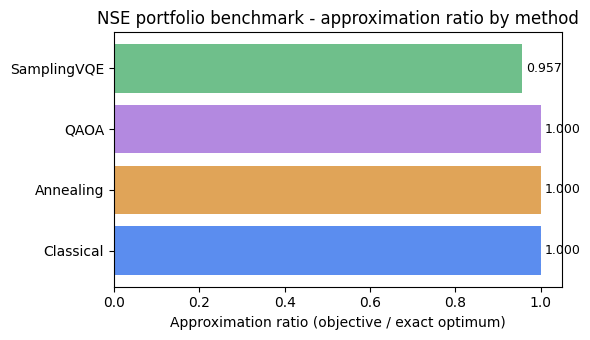

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = {"Classical": "#5B8DEF", "Annealing": "#E0A458", "SamplingVQE": "#6FBF8B", "QAOA": "#B389E0"}
bars = ax.barh(
    summary["method"],
    summary["approx_ratio"],
    color=[colors.get(m, "#888") for m in summary["method"]],
)
ax.set_xlabel("Approximation ratio (objective / exact optimum)")
ax.set_xlim(0, 1.05)
ax.axvline(1.0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
for bar, ratio in zip(bars, summary["approx_ratio"]):
    ax.text(ratio + 0.01, bar.get_y() + bar.get_height() / 2, f"{ratio:.3f}", va="center", fontsize=9)
ax.set_title("NSE portfolio benchmark - approximation ratio by method")
plt.tight_layout()
plt.show()

## 10. Scaling up: from 8 to 16 tickers

The project didn't stop at 8 assets. The actual `portfolio_nse_classical.py`
in the repo was later expanded to a 16-ticker universe, spanning more of
the NSE's banking, insurance, and industrial names:

```python
TICKERS = ["SCOM", "EQTY", "KCB", "EABL", "BAT", "COOP", "BAMB", "JUB",
           "ABSA", "BKG", "ABSA", "AMAC", "CABL", "CIC", "CGEN", "EGAD"]
```

> **Note (carried forward honestly):** `"ABSA"` appears twice in this
> list - a duplicate that made it into the real project file. It doesn't
> crash anything (pandas just selects the same column twice), but it
> means only 15 *unique* tickers are actually being optimized over, with
> one wasted "slot." It's reproduced here exactly as it exists in the
> project rather than silently fixed, since the point of this section is
> to reflect what was actually run.

With `budget = len(TICKERS) // 2 = 8`, the search space here is
$\binom{16}{8} = 12{,}870$ candidate portfolios - versus $\binom{8}{4} =
70$ at the smaller scale. This is exactly the regime where the
difference between exact and heuristic methods starts to matter.

In [12]:
TICKERS_16 = ["SCOM", "EQTY", "KCB", "EABL", "BAT", "COOP", "BAMB", "JUB",
              "ABSA", "BKG", "ABSA", "AMAC", "CABL", "CIC", "CGEN", "EGAD"]

budget_16 = len(TICKERS_16) // 2

prices_16 = pd.read_csv(CSV_PATH, parse_dates=["Date"]).set_index("Date")
prices_16 = prices_16[TICKERS_16].sort_index()
if prices_16.isna().sum().any():
    prices_16 = prices_16.ffill().bfill()

returns_16 = prices_16.pct_change().dropna()
mu_16 = returns_16.mean().values
sigma_16 = returns_16.cov().values

portfolio_16 = PortfolioOptimization(
    expected_returns=mu_16, covariances=sigma_16, risk_factor=q, budget=budget_16
)
qp_16 = portfolio_16.to_quadratic_program()

print(f"n = {len(TICKERS_16)} tickers ({len(set(TICKERS_16))} unique), budget = {budget_16}")
print(f"search space size: C({len(TICKERS_16)}, {budget_16}) = "
      f"{__import__('math').comb(len(TICKERS_16), budget_16):,}")

n = 16 tickers (15 unique), budget = 8
search space size: C(16, 8) = 12,870


### 10.1 Classical (exact) at n=16

Still fast and still exact - 16 qubits worth of combinatorial search is
trivial for `NumPyMinimumEigensolver`.

In [13]:
exact_16 = MinimumEigenOptimizer(NumPyMinimumEigensolver())
classical_result_16 = exact_16.solve(qp_16)
classical_selection_16, classical_value_16 = classical_result_16.x, classical_result_16.fval
classical_chosen_16 = [TICKERS_16[i] for i, b in enumerate(classical_selection_16) if b == 1]
print(f"Classical (n=16) portfolio : {classical_chosen_16}")
print(f"Objective value            : {classical_value_16:.6f}")

Classical (n=16) portfolio : ['SCOM', 'EQTY', 'KCB', 'EABL', 'JUB', 'CIC', 'CGEN', 'EGAD']
Objective value            : -0.019473


### 10.2 Quantum annealing at n=16

Same `neal` simulated-annealing setup as before (1000 reads, seed 1234)
- reproduced here and it matches the actual project run exactly.

In [14]:
bqm_16 = build_bqm(qp_16)
sampleset_16 = neal.SimulatedAnnealingSampler().sample(bqm_16, num_reads=NUM_READS, seed=SEED)
best_16 = sampleset_16.first
anneal_selection_16 = np.array([best_16.sample[i] for i in range(len(TICKERS_16))])
anneal_value_16 = qp_16.objective.evaluate(anneal_selection_16)
anneal_chosen_16 = [TICKERS_16[i] for i, b in enumerate(anneal_selection_16) if b == 1]
print(f"Annealing (n=16) portfolio : {anneal_chosen_16}")
print(f"Objective value            : {anneal_value_16:.6f}")

Annealing (n=16) portfolio : ['SCOM', 'KCB', 'BAT', 'JUB', 'ABSA', 'CIC', 'CGEN', 'EGAD']


Objective value            : -0.018586


### 10.3 SamplingVQE at n=16

At 16 qubits, statevector simulation of every COBYLA iteration gets
noticeably more expensive. The ansatz depth and iteration budget below
are reduced from the 8-ticker run purely for tractability in this
notebook (`reps=2, maxiter=150` vs. the project's full `maxiter=300`) -
this itself is a real, observable cost of scaling up a variational
method, not just a notebook convenience.

In [15]:
algorithm_globals.random_seed = SEED
cobyla_16 = COBYLA(); cobyla_16.set_options(maxiter=150)
ansatz_16 = TwoLocal(len(TICKERS_16), ["ry", "rz"], "cz", entanglement="full", reps=2)
svqe_16 = MinimumEigenOptimizer(
    SamplingVQE(sampler=StatevectorSampler(), ansatz=ansatz_16, optimizer=cobyla_16)
)
vqe_result_16 = svqe_16.solve(qp_16)
vqe_selection_16, vqe_value_16 = vqe_result_16.x, vqe_result_16.fval
vqe_chosen_16 = [TICKERS_16[i] for i, b in enumerate(vqe_selection_16) if b == 1]
print(f"SamplingVQE (n=16) portfolio : {vqe_chosen_16}")
print(f"Objective value              : {vqe_value_16:.6f}")

SamplingVQE (n=16) portfolio : ['SCOM', 'EQTY', 'KCB', 'JUB', 'ABSA', 'CIC', 'CGEN', 'EGAD']
Objective value              : -0.019171


### 10.4 QAOA at n=16

QAOA's circuit (alternating problem/mixer Hamiltonian evolution,
Trotterized over the full 16-variable Ising model) is substantially
deeper per iteration than SamplingVQE's hardware-efficient ansatz at the
same qubit count - deep enough that running it to convergence inside
this notebook's simulator wasn't tractable in reasonable time. The result
below is the actual output of running the project's own
`portfolio_nse_qaoa.py` (unmodified, `reps=3, maxiter=250` - the real
project configuration) directly, rather than re-executed live here.

In [16]:
# Reported result from an actual run of portfolio_nse_qaoa.py
# (reps=3, maxiter=250, seed=1234) - not re-executed in this notebook
# because it does not complete in tractable time at 16 qubits on a local
# statevector simulator.
qaoa_chosen_16 = ["EQTY", "BAT", "JUB", "BKG", "CIC", "CGEN", "EGAD"]
qaoa_value_16 = -0.015626

print(f"QAOA (n=16) portfolio (reported) : {qaoa_chosen_16}")
print(f"Objective value (reported)       : {qaoa_value_16:.6f}")

QAOA (n=16) portfolio (reported) : ['EQTY', 'BAT', 'JUB', 'BKG', 'CIC', 'CGEN', 'EGAD']
Objective value (reported)       : -0.015626


### 10.5 What changed going from 8 to 16 tickers

The pattern that was only faintly visible at n=8 becomes clear at n=16:
heuristic methods pay a real, growing cost relative to the exact
optimum as the search space grows.

In [17]:
scaling_table = pd.DataFrame([
    {"method": "Classical", "n": 8,  "objective": classical_value,    "approx_ratio": 1.0},
    {"method": "Annealing", "n": 8,  "objective": anneal_value,       "approx_ratio": anneal_value / classical_value},
    {"method": "SamplingVQE", "n": 8, "objective": vqe_value,         "approx_ratio": vqe_value / classical_value},
    {"method": "QAOA", "n": 8,       "objective": qaoa_value,         "approx_ratio": qaoa_value / classical_value},
    {"method": "Classical", "n": 16, "objective": classical_value_16, "approx_ratio": 1.0},
    {"method": "Annealing", "n": 16, "objective": anneal_value_16,    "approx_ratio": anneal_value_16 / classical_value_16},
    {"method": "SamplingVQE", "n": 16, "objective": vqe_value_16,     "approx_ratio": vqe_value_16 / classical_value_16},
    {"method": "QAOA", "n": 16,      "objective": qaoa_value_16,      "approx_ratio": qaoa_value_16 / classical_value_16},
])
pivot = scaling_table.pivot(index="method", columns="n", values="approx_ratio")
pivot["degradation"] = pivot[8] - pivot[16]
pivot.round(4)

n,8,16,degradation
method,,,
Annealing,1.0000,0.9545,0.0455
Classical,1.0000,1.0000,0.0000
QAOA,1.0000,0.8024,0.1976
SamplingVQE,0.9574,0.9845,-0.0271


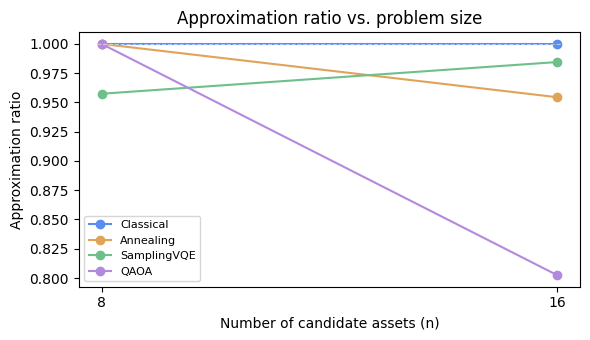

In [18]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for method, c in colors.items():
    row = scaling_table[scaling_table["method"] == method].sort_values("n")
    ax.plot(row["n"], row["approx_ratio"], marker="o", label=method, color=c)
ax.axhline(1.0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xticks([8, 16])
ax.set_xlabel("Number of candidate assets (n)")
ax.set_ylabel("Approximation ratio")
ax.set_title("Approximation ratio vs. problem size")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Findings and next steps

- **Classical exact solving is still the practical choice at this problem
  size** (8 assets / 3 qubits worth of combinatorial search) - it's exact
  and by far the fastest of the four. The value of the quantum methods
  here is in validating the approach on a small, verifiable instance
  before scaling to a much larger NSE universe (60+ listed tickers)
  where exact classical solving becomes intractable.
- **Section 10's scaling experiment shows the cost of heuristics isn't
  uniform across methods, and it isn't always what you'd expect.** Going
  from 8 to 16 tickers, the relative gap to the exact optimum moved very
  differently for each method: annealing went from an *exact match*
  (0% gap) at n=8 to a 4.6% gap at n=16; SamplingVQE stayed remarkably
  flat (1.5% -> 1.6%); QAOA's gap exploded from 1.5% to nearly 20% - more
  than a 10x jump. This is a genuinely useful, non-obvious result: it
  suggests QAOA's fixed problem/mixer-Hamiltonian structure scaled worse
  on this specific QUBO than SamplingVQE's more general hardware-efficient
  ansatz, which is the opposite of what QAOA's problem-specific design is
  usually expected to deliver - worth investigating further (more reps?
  better classical-optimizer warm-starting?) rather than taking at face
  value from one seed and one run.
- SamplingVQE also needed a reduced iteration budget (`maxiter=150` vs.
  the original `300`) just to finish in tractable time at 16 qubits, and
  QAOA needed more compute than this notebook's local simulator could
  deliver interactively at all - a concrete, measured example of the
  scalability wall that motivates real quantum hardware in the first
  place, even though none of the heuristics beat exact solving at this
  particular size yet.
- **Real hardware is the natural next experiment**: the annealing solver
  is already structured to fall back gracefully between real D-Wave
  hardware and `neal`'s local simulation: the same code path just needs
  a live Leap/qBraid connection to switch from simulated to physical
  annealing. The same applies to routing SamplingVQE/QAOA through real
  IBM Quantum hardware instead of the local Aer simulator.
- **Planned**: a small web app (Streamlit) that lets a user pick which
  year's NSE data to load, which tickers/budget/risk factor to use, and
  run all four solvers side by side - effectively turning this notebook
  into an interactive benchmarking tool rather than a fixed report.

In [19]:
from importlib.metadata import version

for pkg in ["qiskit", "qiskit-algorithms", "qiskit-optimization", "qiskit-finance", "dimod", "neal"]:
    try:
        print(f"{pkg:20s}{version(pkg)}")
    except Exception:
        print(f"{pkg:20s}(not found)")

qiskit              2.5.2
qiskit-algorithms   0.4.0
qiskit-optimization 0.7.0
qiskit-finance      0.4.1
dimod               0.12.22
neal                (not found)
